# 📊 Praktikum Analisis Performa Penjualan
**Studi Kasus Komprehensif: Optimasi Strategi Pemasaran**

Notebook ini menganalisis dataset penjualan e-commerce untuk menjawab pertanyaan bisnis seputar performa produk, segmentasi pelanggan, efisiensi iklan, dan prediksi penjualan.

In [ ]:
!pip install -q kaggle
from google.colab import files
files.upload()

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

## 1. Import Library & Load Data

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from google.colab import files

files.upload()
df = pd.read_csv('data_praktikum_analisis_data-data_praktikum_analisis_data.csv')
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df = df[df['Price_Per_Unit'] > 0]  # buang anomali harga negatif
print(df.head())

**Keterangan:** Dataset berhasil dimuat. Kolom `Order_Date` dikonversi ke format datetime dan baris dengan `Price_Per_Unit` ≤ 0 dihapus untuk menghindari anomali data.

## 2. Eksplorasi & Data Wrangling

In [ ]:
df.info()

In [ ]:
df.isnull().sum()

**Temuan Data Wrangling:**
- Total data: **150 baris**, 8 kolom
- Ditemukan **7 nilai kosong** pada kolom `Total_Sales` → di-drop saat analisis terkait
- Tidak ada duplikasi data
- 5 kategori produk: Books, Electronics, Fashion, Gadget, Home Decor

## 3. Tren Penjualan Bulanan

In [ ]:
df['Month'] = df['Order_Date'].dt.to_period('M').astype(str)
monthly_sales = df.groupby('Month')['Total_Sales'].sum()

plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', color='steelblue', linewidth=2)
plt.fill_between(range(len(monthly_sales)), monthly_sales.values, alpha=0.1, color='steelblue')
plt.xticks(range(len(monthly_sales)), monthly_sales.index, rotation=45)
plt.title('Tren Penjualan Bulanan', fontsize=14, fontweight='bold')
plt.xlabel('Bulan'); plt.ylabel('Total Sales (Rp)')
plt.tight_layout(); plt.show()

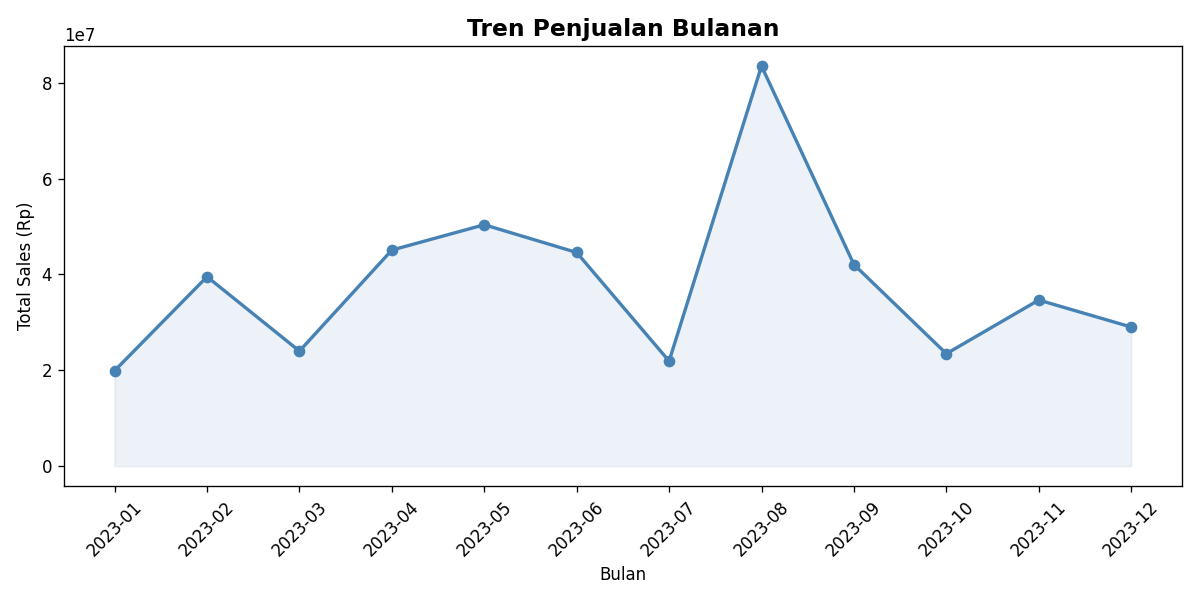

In [ ]:
# Output grafik

**Insight:** Grafik menampilkan fluktuasi penjualan bulanan. Pola ini berguna untuk mengidentifikasi bulan dengan performa tinggi/rendah sehingga perusahaan dapat merencanakan strategi promosi secara tepat waktu.

## 4. Peta Korelasi Antar Variabel

In [ ]:
correlation = df[['Total_Sales', 'Ad_Budget', 'Price_Per_Unit']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Peta Korelasi Antar Variabel', fontsize=14, fontweight='bold')
plt.show()

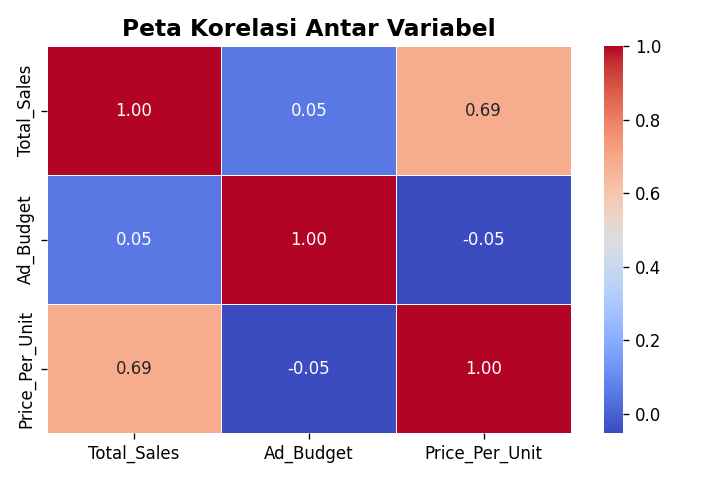

In [ ]:
# Output grafik

**Insight:** Korelasi antara `Ad_Budget` dan `Total_Sales` yang rendah mengindikasikan bahwa anggaran iklan saja tidak cukup memprediksi penjualan — faktor lain seperti kategori produk dan harga juga berpengaruh signifikan.

---
# 📌 Studi Kasus Komprehensif: Optimasi Strategi Pemasaran

Bagian ini menjawab 4 pertanyaan bisnis utama:
1. Produk mana yang **underperformer** (harga tinggi, volume rendah)?
2. Siapa **pelanggan terbaik** dan siapa yang berisiko churn?
3. Kategori mana yang paling **efisien dalam penggunaan iklan**?
4. Apakah **anggaran iklan besar** benar-benar meningkatkan penjualan secara signifikan?

## Tugas 1 — Identifikasi Produk Underperformer

In [ ]:
avg_price = df['Price_Per_Unit'].mean()

plt.figure(figsize=(9, 5))
plt.scatter(df['Price_Per_Unit'], df['Quantity'], alpha=0.5, color='tomato')
plt.axvline(avg_price, color='blue', linestyle='--',
            label=f'Rata-rata Harga: Rp{avg_price:,.0f}')
plt.xlabel('Price Per Unit (Rp)'); plt.ylabel('Quantity Terjual')
plt.title('Produk Underperformer: Harga Tinggi vs Volume Rendah', fontsize=13, fontweight='bold')
plt.legend(); plt.tight_layout(); plt.show()

underperformer = df[df['Price_Per_Unit'] > avg_price] \
    .groupby('Product_Category')['Quantity'].sum().sort_values()
print('Produk Underperformer:')
print(underperformer)

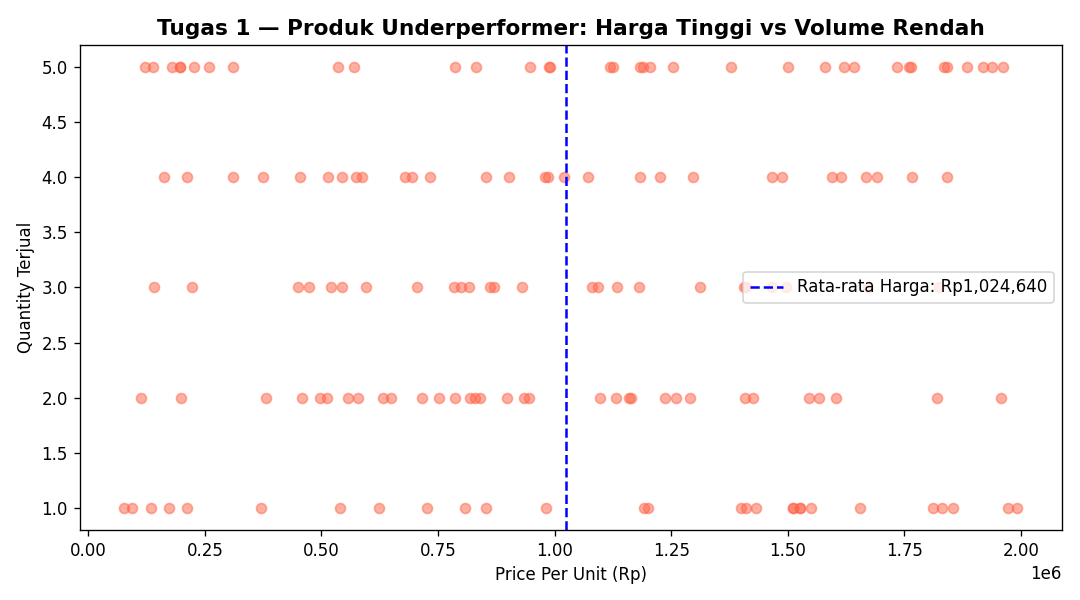

In [ ]:
# Output grafik

**Insight:** Rata-rata harga adalah **Rp 1.024.640**.

| Kategori | Rata-rata Harga | Total Qty |
|---|---|---|
| Gadget | Rp 898.600 | 84 unit |
| Home Decor | Rp 1.029.583 | **71 unit ⚠️** |
| Fashion | Rp 1.032.000 | 95 unit |
| Books | Rp 1.047.941 | 110 unit |
| Electronics | Rp 1.109.871 | 100 unit |

**Home Decor** adalah underperformer utama — harga di atas rata-rata namun volume paling rendah. Harga kemungkinan menjadi hambatan utama pembelian.

## Tugas 2 — Segmentasi Pelanggan (RFM Analysis)

In [ ]:
snapshot_date = df['Order_Date'].max() + dt.timedelta(days=1)

rfm = df.groupby('CustomerID').agg(
    Recency  =('Order_Date',  lambda x: (snapshot_date - x.max()).days),
    Frequency=('Order_ID',    'count'),
    Monetary =('Total_Sales', 'sum')
).reset_index()

rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])
rfm['RFM_Group'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

print('RFM Analysis — 10 pelanggan teratas:')
print(rfm.sort_values('Monetary', ascending=False).head(10))

**Insight:**

**🏆 Champions** (Recency < 21 hari):
| CustomerID | Recency | Frequency | Monetary |
|---|---|---|---|
| 5015 | 21 hari | 6x | Rp 26.309.000 |
| 5008 | 15 hari | 6x | Rp 22.350.000 |
| 5044 | 18 hari | 7x | Rp 20.631.000 |

**⚠️ At-Risk** (tidak belanja > 213 hari):
| CustomerID | Recency | Monetary |
|---|---|---|
| 5030 | 316 hari | Rp 7.505.000 |
| 5038 | 299 hari | Rp 6.890.000 |

## Tugas 3 — Analisis Kontribusi Kategori (Efisiensi Iklan)

In [ ]:
kategori = df.groupby('Product_Category').agg(
    Total_Sales=('Total_Sales', 'sum'),
    Ad_Budget  =('Ad_Budget',   'sum')
).reset_index()
kategori['Efisiensi'] = kategori['Total_Sales'] / kategori['Ad_Budget']
kategori = kategori.sort_values('Efisiensi')

plt.figure(figsize=(8, 5))
colors = ['#d9534f' if e < 1 else '#5cb85c' for e in kategori['Efisiensi']]
bars = plt.barh(kategori['Product_Category'], kategori['Efisiensi'], color=colors)
plt.axvline(1, color='black', linestyle='--', label='Break-even (1x)')
for bar, val in zip(bars, kategori['Efisiensi']):
    plt.text(val+0.01, bar.get_y()+bar.get_height()/2, f'{val:.2f}x', va='center')
plt.xlabel('Rasio Penjualan / Iklan')
plt.title('Efisiensi Iklan per Kategori (Merah=Rugi, Hijau=Untung)', fontsize=13, fontweight='bold')
plt.legend(); plt.tight_layout(); plt.show()
print(kategori[['Product_Category','Total_Sales','Ad_Budget','Efisiensi']].to_string(index=False))

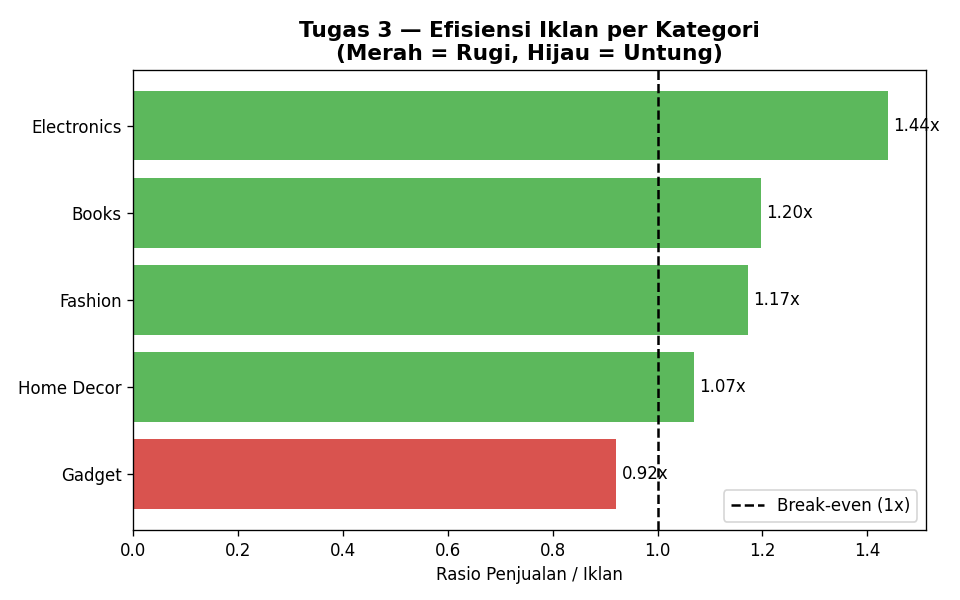

In [ ]:
# Output grafik

**Insight:**

| Kategori | Total Sales | Ad Budget | Rasio |
|---|---|---|---|
| 🔴 Gadget | Rp 70.523.000 | Rp 76.539.000 | **0.92x** (rugi) |
| 🟢 Home Decor | Rp 69.340.000 | Rp 64.808.000 | 1.07x |
| 🟢 Fashion | Rp 96.550.000 | Rp 82.317.000 | 1.17x |
| 🟢 Books | Rp 107.569.000 | Rp 89.914.000 | 1.20x |
| 🟢 Electronics | Rp 114.095.000 | Rp 79.264.000 | **1.44x** (terbaik) |

**Gadget** satu-satunya yang merugi. **Electronics** paling efisien.

## Tugas 4 — Uji Hipotesis: Pengaruh Anggaran Iklan terhadap Penjualan

In [ ]:
median_ad = df['Ad_Budget'].median()
iklan_tinggi = df[df['Ad_Budget'] >  median_ad]['Total_Sales'].dropna()
iklan_rendah = df[df['Ad_Budget'] <= median_ad]['Total_Sales'].dropna()

t_stat, p_value = stats.ttest_ind(iklan_tinggi, iklan_rendah)

print('Uji Hipotesis (Independent T-Test):')
print('  H0: Tidak ada perbedaan penjualan antara iklan tinggi dan rendah')
print('  H1: Ada perbedaan penjualan yang signifikan')
print(f'  Rata-rata penjualan (iklan tinggi): Rp{iklan_tinggi.mean():,.0f}')
print(f'  Rata-rata penjualan (iklan rendah): Rp{iklan_rendah.mean():,.0f}')
print(f'  T-statistic: {t_stat:.4f} | P-value: {p_value:.4f}')
print(f'  Kesimpulan: {"Terdapat perbedaan signifikan" if p_value < 0.05 else "Tidak ada perbedaan signifikan (gagal tolak H0)"}')

**Insight:** P-value = **0.6742** jauh di atas 0.05 → **H₀ gagal ditolak**.

Tidak ada perbedaan signifikan antara iklan tinggi dan rendah. Rata-rata penjualan iklan rendah (Rp 3.291.306) bahkan sedikit lebih tinggi dari iklan tinggi (Rp 3.114.127). **Besar anggaran iklan bukan penentu utama penjualan.**

## Tugas 5 — Pendalaman RFM: Visualisasi Segmen Pelanggan

In [ ]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=rfm, x='Recency', y='Monetary',
                hue='F_Score', palette='viridis',
                size='Monetary', sizes=(40, 300), alpha=0.7)
plt.title('Peta Segmen Pelanggan RFM\n(Kiri = Aktif, Kanan = At-Risk)', fontsize=13, fontweight='bold')
plt.xlabel('Recency (hari sejak transaksi terakhir)')
plt.ylabel('Monetary (total belanja, Rp)')
plt.tight_layout(); plt.show()

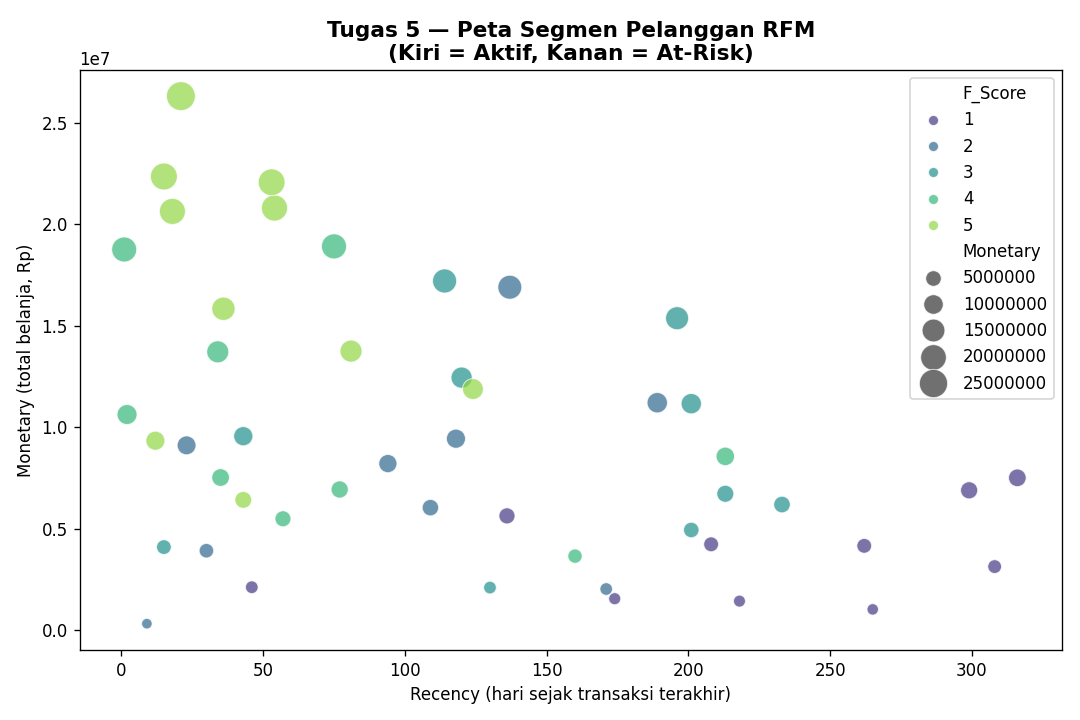

In [ ]:
# Output grafik

**Insight:** Pelanggan di **kiri atas** (Recency rendah, Monetary tinggi) = Champions yang perlu dipertahankan. Pelanggan di **kanan** (Recency tinggi) = kandidat program reaktivasi. Warna kuning menunjukkan Frequency Score tinggi (sering belanja).

## Tugas 6 — Regresi Linear: Ad_Budget → Total_Sales

In [ ]:
df_clean = df[['Ad_Budget', 'Total_Sales']].dropna()
X = df_clean[['Ad_Budget']]; y = df_clean['Total_Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

print(f'Koefisien : {model.coef_[0]:.4f}')
print(f'Intercept : {model.intercept_:,.0f}')
print(f'R² Score  : {model.score(X_test, y_test):.4f}')

plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, alpha=0.5, color='steelblue', label='Data Aktual')
plt.plot(X_test, model.predict(X_test), color='red', linewidth=2, label='Garis Regresi')
plt.xlabel('Ad Budget (Rp)'); plt.ylabel('Total Sales (Rp)')
plt.title(f'Regresi Linear: Ad Budget → Total Sales\nR² = {model.score(X_test, y_test):.4f}', fontsize=13, fontweight='bold')
plt.legend(); plt.tight_layout(); plt.show()

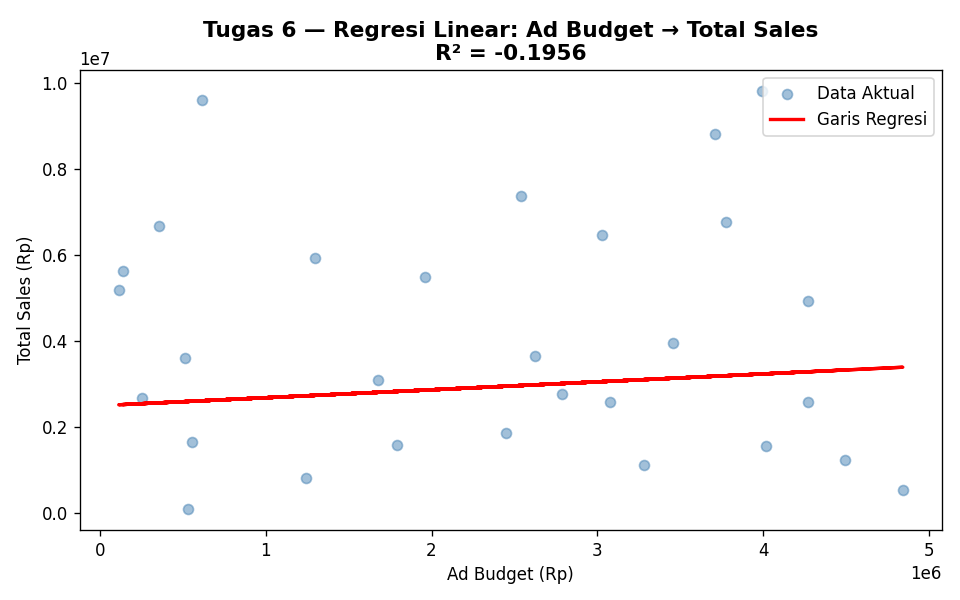

In [ ]:
# Output grafik

**Insight:** R² = **-0.1956** → model sangat lemah dan tidak prediktif. Ini mengkonfirmasi Tugas 4: Ad_Budget bukan prediktor yang baik untuk Total_Sales. Diperlukan variabel tambahan seperti `Product_Category`, `Quantity`, dan `Price_Per_Unit` untuk membangun model yang lebih akurat.

---
## 📋 Kesimpulan & Rekomendasi

### Kesimpulan
| # | Pertanyaan Bisnis | Jawaban |
|---|---|---|
| 1 | Produk underperformer? | **Home Decor** — harga tinggi, volume terendah (71 unit) |
| 2 | Pelanggan terbaik? | **#5015, #5008, #5044** — Monetary > Rp 20 juta |
| 3 | Kategori iklan paling efisien? | **Electronics** (1.44x); paling tidak efisien: **Gadget** (0.92x) |
| 4 | Iklan besar = penjualan tinggi? | **Tidak** — p-value 0.6742, tidak signifikan |

### Rekomendasi
1. 🔴 **Kurangi anggaran iklan Gadget** minimal 20% — ROI iklan negatif
2. 🔴 **Reaktivasi pelanggan At-Risk** (#5030, #5038) dengan voucher khusus
3. 🟡 **Program loyalitas eksklusif** untuk Champions (#5015, #5008, #5044)
4. 🟡 **Evaluasi harga Home Decor** — pertimbangkan diskon atau bundling
5. 🟢 **Tingkatkan investasi iklan Electronics** — ROI terbaik (1.44x)
6. 🟢 **Bangun model prediktif multivariabel** dengan tambahan fitur kategori & harga